# Análisis de Resultados ML - TMT SSRT

In [1]:
import sys
from pathlib import Path

# Find project root (directory containing src/)
_p = Path().resolve()
while not (_p / 'src').is_dir() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

import pandas as pd
from src.config import REGRESSION_ANALYSIS_FOLDER

# Load latest consolidated results
consolidated_dir = Path(REGRESSION_ANALYSIS_FOLDER) / "consolidated"
consolidated_path = sorted(consolidated_dir.glob("combined_summary_with_dispersion_*.csv"))[-1]
df_all = pd.read_csv(consolidated_path)

# Filter for this notebook's target and dataset
TARGET = "ssrt"
DATASET = "tmt_ssrt"
df = df_all[(df_all["target"] == TARGET) & (df_all["dataset"] == DATASET)].reset_index(drop=True)
print(f"Loaded from: {consolidated_path.name}")
df

Loaded from: combined_summary_with_dispersion_2026-02-03_2051_2026-02-03_2053_2026-02-05_2206.csv


,model,r2,mse,mae,y_true,y_pred,target,dataset,sd_y_true,iqr_y_true,p_value_mae
0,RandomForestRegressor,-0.115545,2952.228661,42.644893,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[240.1243797445866, 230.65971466919598, 224.62...",ssrt,tmt_ssrt,51.595577,62.25,0.999001
1,DummyRegressor,-0.011869,2677.855677,40.150644,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[224.36094674556213, 224.97041420118344, 224.5...",ssrt,tmt_ssrt,51.595577,62.25,1.000000
2,LinearRegression,-0.192634,3156.238885,45.079147,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[278.93216204504773, 239.74318894745468, 247.7...",ssrt,tmt_ssrt,51.595577,62.25,0.968032
3,Ridge,-0.012130,2678.546828,40.261444,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[226.96755048317127, 225.60386274889458, 225.7...",ssrt,tmt_ssrt,51.595577,62.25,0.995005
4,Lasso,-0.014030,2683.573457,40.202553,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[224.36094674556213, 224.97041420118344, 224.5...",ssrt,tmt_ssrt,51.595577,62.25,1.000000
5,XGBRegressor,-0.259077,3332.076771,44.818549,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[228.9246826171875, 243.1316680908203, 219.758...",ssrt,tmt_ssrt,51.595577,62.25,0.561439
6,ElasticNet,-0.012204,2678.740769,40.159744,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[224.36094674556213, 224.97041420118344, 224.5...",ssrt,tmt_ssrt,51.595577,62.25,1.000000
7,SVR,-0.015228,2686.743890,39.997860,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[232.59458690035575, 230.80930426006248, 231.3...",ssrt,tmt_ssrt,51.595577,62.25,0.796204


In [2]:
import sys
sys.path.insert(0, '..')

from src.model.datasetbuilder.dataset_builder import DatasetBuilder

# Cargar el dataset usado para los modelos
builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset('tmt_ssrt')

# Crear DataFrame con los features para explorar
df_features = pd.DataFrame(X, columns=feature_names)
df_features['target'] = y

print(f"Dataset: tmt_ssrt")
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Target: {target_name}")
df_features.head()

Dataset: tmt_ssrt
Samples: 170, Features: 134
Target: ssrt


,area_difference_from_ideal_PART_A,area_difference_from_ideal_PART_B,average_duration_PART_A,average_duration_PART_B,correct_targets_touches_PART_A,correct_targets_touches_PART_B,distance_difference_from_ideal_PART_A,distance_difference_from_ideal_PART_B,hesitation_avg_speed_PART_A,hesitation_avg_speed_PART_B,...,travel_avg_speed_PART_B,travel_distance_PART_A,travel_distance_PART_B,travel_time_PART_A,travel_time_PART_B,valid_interval_count_PART_A,valid_interval_count_PART_B,wrong_targets_touches_PART_A,wrong_targets_touches_PART_B,target
0,1248.241760,1796.087299,405.648148,254.833333,10.0,10.0,24.640867,27.778190,0.104522,0.119332,...,0.229479,646.745078,535.078794,2243.666667,2366.500000,758.000000,757.000000,0.0,0.0,235
1,2413.761789,1812.318829,228.515133,243.894136,10.0,10.0,30.372466,28.551063,0.230457,0.215996,...,0.427479,582.482537,505.496986,1315.100000,1163.222222,495.600000,728.555556,0.0,0.0,132
2,1912.416306,2522.437769,250.837654,427.569841,10.0,10.0,25.773707,37.600730,0.199273,0.165295,...,0.347062,571.831044,441.058361,1491.222222,1237.555556,397.888889,593.111111,0.0,0.0,205
3,562.414053,1019.843303,83.178571,153.171429,10.0,10.0,16.217879,15.335298,0.216958,0.225781,...,0.337168,632.437384,774.719988,1759.000000,2284.000000,405.000000,945.500000,0.0,0.0,94
4,1689.909682,2211.550752,233.660556,220.447619,10.0,10.0,26.080216,31.505984,0.164402,0.166642,...,0.337950,699.883714,694.794568,2243.400000,2037.500000,456.300000,588.000000,0.0,0.0,175


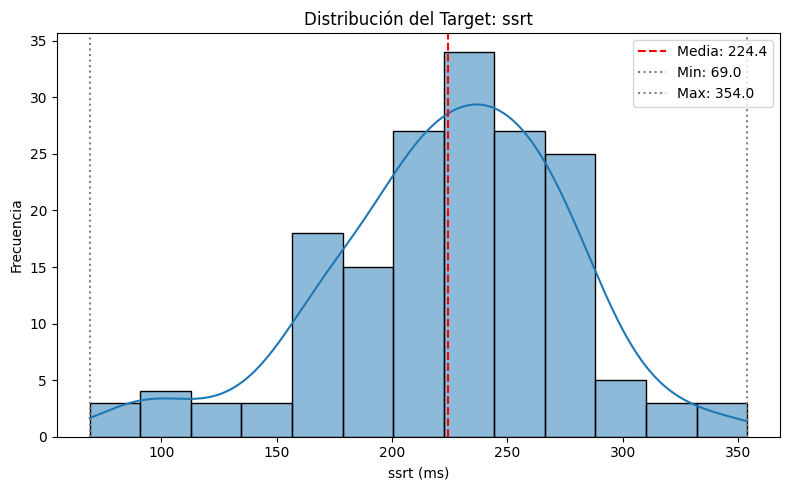

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y, kde=True, ax=ax)
ax.set_xlabel(f'{target_name} (ms)')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución del Target: {target_name}')
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.1f}')
ax.axvline(y.min(), color='gray', linestyle=':', label=f'Min: {y.min():.1f}')
ax.axvline(y.max(), color='gray', linestyle=':', label=f'Max: {y.max():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

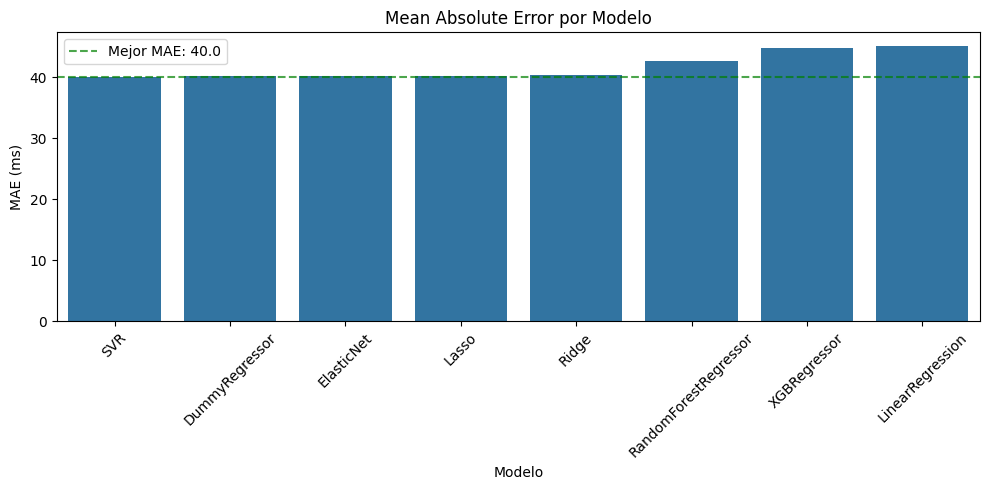

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
df_sorted = df.sort_values('mae')
sns.barplot(data=df_sorted, x='model', y='mae', ax=ax)
ax.set_xlabel('Modelo')
ax.set_ylabel('MAE (ms)')
ax.set_title('Mean Absolute Error por Modelo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(df['mae'].min(), color='green', linestyle='--', alpha=0.7, label=f'Mejor MAE: {df["mae"].min():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## Fase 1: Validación del Pipeline

Verificamos la configuración del pipeline de ML utilizado.

In [5]:
from src.config import REGRESSION_MODELS, PERFORM_FEATURE_SELECTION, MAX_SELECTED_FEATURES, TUNE_HYPERPARAMETERS

print("=== Configuración del Pipeline ===")
print(f"Feature selection: {PERFORM_FEATURE_SELECTION}")
print(f"Max features seleccionados (k): {MAX_SELECTED_FEATURES}")
print(f"Hyperparameter tuning: {TUNE_HYPERPARAMETERS}")
print(f"\nModelos evaluados: {[type(m).__name__ for m in REGRESSION_MODELS(42)]}")
print(f"\nDataset: {X.shape[0]} sujetos × {X.shape[1]} features → {MAX_SELECTED_FEATURES} features seleccionados")

=== Configuración del Pipeline ===
Feature selection: True
Max features seleccionados (k): 20
Hyperparameter tuning: True

Modelos evaluados: ['DummyRegressor', 'LinearRegression', 'Ridge', 'Lasso', 'XGBRegressor', 'ElasticNet', 'SVR', 'RandomForestRegressor']

Dataset: 170 sujetos × 134 features → 20 features seleccionados


## Fase 2: Análisis del Target (SSRT)

Analizamos la distribución del target para entender mejor el problema.

In [6]:
import numpy as np
from scipy import stats

print("=== Estadísticas del Target (SSRT) ===")
print(f"Media: {y.mean():.1f} ms")
print(f"Desviación estándar: {y.std():.1f} ms")
print(f"Mediana: {np.median(y):.1f} ms")
print(f"Rango: [{y.min()}, {y.max()}] ms")
print(f"Coeficiente de variación: {100*y.std()/y.mean():.1f}%")

print(f"\n=== Forma de la distribución ===")
print(f"Skewness: {stats.skew(y):.3f}")
print(f"Kurtosis: {stats.kurtosis(y):.3f}")
shapiro_stat, shapiro_p = stats.shapiro(y)
print(f"Test Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print(f"→ Distribución {'normal' if shapiro_p > 0.05 else 'NO normal'} (α=0.05)")

print(f"\n=== Detección de Outliers (IQR) ===")
q1, q3 = np.percentile(y, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
outliers_mask = (y < lower_bound) | (y > upper_bound)
n_outliers = outliers_mask.sum()
print(f"Q1: {q1:.1f}, Q3: {q3:.1f}, IQR: {iqr:.1f}")
print(f"Límites: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Outliers: {n_outliers} ({100*n_outliers/len(y):.1f}%)")
if n_outliers > 0:
    print(f"Valores outlier: {y[outliers_mask]}")

=== Estadísticas del Target (SSRT) ===
Media: 224.4 ms
Desviación estándar: 51.4 ms
Mediana: 228.5 ms
Rango: [69, 354] ms
Coeficiente de variación: 22.9%

=== Forma de la distribución ===
Skewness: -0.500
Kurtosis: 0.514
Test Shapiro-Wilk: W=0.9784, p=0.0095
→ Distribución NO normal (α=0.05)

=== Detección de Outliers (IQR) ===
Q1: 195.5, Q3: 257.8, IQR: 62.2
Límites: [102.1, 351.1]
Outliers: 7 (4.1%)
Valores outlier: [ 94 100  89  91  69  88 354]


## Fase 3: Análisis de Métricas por Modelo

Comparamos el rendimiento de todos los modelos contra el baseline (DummyRegressor).

In [7]:
df_metrics = df[['model', 'r2', 'mse', 'mae']].copy()

# Calcular diferencia vs baseline
baseline_mae = df_metrics[df_metrics['model']=='DummyRegressor']['mae'].values[0]
df_metrics['mae_vs_baseline'] = df_metrics['mae'] - baseline_mae
df_metrics['mae_vs_baseline_pct'] = 100 * df_metrics['mae_vs_baseline'] / baseline_mae

# Ordenar por MAE y agregar ranking
df_metrics = df_metrics.sort_values('mae')
df_metrics['rank'] = range(1, len(df_metrics)+1)

# Agregar interpretación
def interpret_r2(r2):
    if r2 < 0:
        return "❌ Peor que baseline"
    elif r2 < 0.1:
        return "⚠️ Muy débil"
    elif r2 < 0.3:
        return "⚠️ Débil"
    elif r2 < 0.5:
        return "✅ Moderado"
    else:
        return "✅ Bueno"

df_metrics['interpretacion'] = df_metrics['r2'].apply(interpret_r2)

print("=== Tabla Comparativa de Modelos ===\n")
display(df_metrics[['rank', 'model', 'r2', 'mae', 'mae_vs_baseline', 'interpretacion']])

print(f"\n=== Interpretación ===")
print(f"MAE del baseline (DummyRegressor): {baseline_mae:.2f} ms")
print(f"Mejor MAE: {df_metrics['mae'].min():.2f} ms ({df_metrics['model'].iloc[0]})")
print(f"Error relativo (MAE/media): {100*baseline_mae/y.mean():.1f}%")
print(f"Error relativo (MAE/std): {100*baseline_mae/y.std():.1f}% de una desviación estándar")
print(f"\n⚠️ HALLAZGO CRÍTICO: Todos los R² son negativos")
print(f"   Esto significa que NINGÚN modelo supera el baseline de predecir la media.")

=== Tabla Comparativa de Modelos ===



,rank,model,r2,mae,mae_vs_baseline,interpretacion
7,1,SVR,-0.015228,39.997860,-0.152784,❌ Peor que baseline
1,2,DummyRegressor,-0.011869,40.150644,0.000000,❌ Peor que baseline
6,3,ElasticNet,-0.012204,40.159744,0.009100,❌ Peor que baseline
4,4,Lasso,-0.014030,40.202553,0.051909,❌ Peor que baseline
3,5,Ridge,-0.012130,40.261444,0.110800,❌ Peor que baseline
0,6,RandomForestRegressor,-0.115545,42.644893,2.494249,❌ Peor que baseline
5,7,XGBRegressor,-0.259077,44.818549,4.667905,❌ Peor que baseline
2,8,LinearRegression,-0.192634,45.079147,4.928503,❌ Peor que baseline



=== Interpretación ===
MAE del baseline (DummyRegressor): 40.15 ms
Mejor MAE: 40.00 ms (SVR)
Error relativo (MAE/media): 17.9%
Error relativo (MAE/std): 78.0% de una desviación estándar

⚠️ HALLAZGO CRÍTICO: Todos los R² son negativos
   Esto significa que NINGÚN modelo supera el baseline de predecir la media.


## Fase 4: Análisis de Residuos y Predicciones

Visualizamos las predicciones vs valores reales para cada modelo.

In [8]:
# Cargar datos por fold (buscar el más reciente para este target/dataset)
from src.config import REGRESSION_RESULTS_DIR

folds_path = sorted(Path(REGRESSION_RESULTS_DIR).glob(f"*/{TARGET}/{DATASET}/folds.csv"))[-1]
folds = pd.read_csv(folds_path)
print(f"Folds cargados desde: {folds_path.parts[-4]} (timestamp)")
print(f"{folds.shape[0]} filas ({folds['model'].nunique()} modelos x {folds['fold'].nunique()} folds)")

Folds cargados desde: 2026-02-03_2053 (timestamp)
1190 filas (7 modelos x 170 folds)


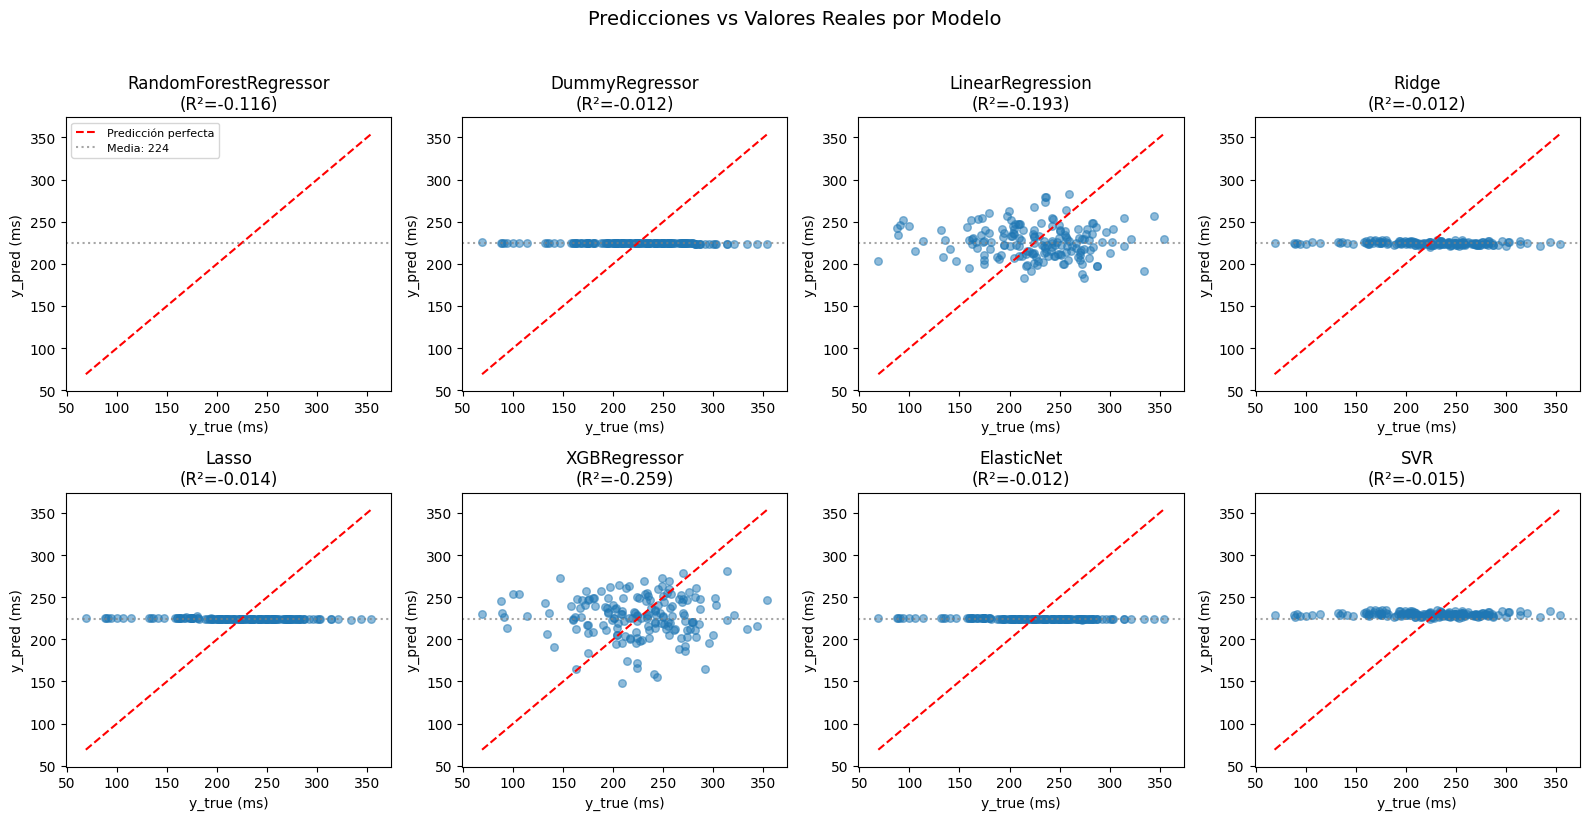


📊 Observación: Los modelos regularizados (Ridge, Lasso, ElasticNet, SVR) predicen cerca de la media
   mientras que los modelos más complejos (XGB, RF, LinearRegression) tienen mayor varianza pero peor rendimiento.


In [9]:
# Scatter plots: Predicciones vs Valores Reales
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
models = df['model'].unique()

for ax, model in zip(axes.flat, models):
    model_folds = folds[folds['model'] == model]
    
    ax.scatter(model_folds['y_test'], model_folds['y_pred'], alpha=0.5, s=30)
    
    # Línea de predicción perfecta
    min_val, max_val = y.min(), y.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
    
    # Línea de predicción media (baseline)
    ax.axhline(y.mean(), color='gray', linestyle=':', alpha=0.7, label=f'Media: {y.mean():.0f}')
    
    # Calcular R² para este modelo
    r2_model = df[df['model']==model]['r2'].values[0]
    ax.set_title(f'{model}\n(R²={r2_model:.3f})')
    ax.set_xlabel('y_true (ms)')
    ax.set_ylabel('y_pred (ms)')
    ax.set_xlim(min_val - 20, max_val + 20)
    ax.set_ylim(min_val - 20, max_val + 20)

axes[0, 0].legend(loc='upper left', fontsize=8)
plt.suptitle('Predicciones vs Valores Reales por Modelo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Observación: Los modelos regularizados (Ridge, Lasso, ElasticNet, SVR) predicen cerca de la media")
print("   mientras que los modelos más complejos (XGB, RF, LinearRegression) tienen mayor varianza pero peor rendimiento.")

In [10]:
# Análisis de residuos para modelos seleccionados
print("=== Análisis de Residuos ===\n")

for model in ['Ridge', 'XGBRegressor', 'DummyRegressor']:
    model_folds = folds[folds['model'] == model]
    residuals = model_folds['y_pred'] - model_folds['y_test']
    
    print(f"{model}:")
    print(f"  Residuos: mean={residuals.mean():.2f}, std={residuals.std():.2f}")
    print(f"  Rango residuos: [{residuals.min():.1f}, {residuals.max():.1f}]")
    print()

=== Análisis de Residuos ===

Ridge:
  Residuos: mean=0.01, std=51.91
  Rango residuos: [-130.7, 155.6]

XGBRegressor:
  Residuos: mean=2.39, std=57.84
  Rango residuos: [-128.1, 161.1]

DummyRegressor:
  Residuos: mean=-0.00, std=51.90
  Rango residuos: [-130.3, 156.3]



## Fase 5: Análisis de Feature Selection

Analizamos qué features fueron seleccionados más frecuentemente a través de los folds.

In [11]:
import ast
from collections import Counter

# Parsear features seleccionados (usar Ridge como referencia)
ridge_folds = folds[folds['model'] == 'Ridge'].copy()

# Contar frecuencia de cada feature
all_selected = []
for features_str in ridge_folds['select_k_best_features']:
    try:
        features = ast.literal_eval(features_str)
        all_selected.extend(features)
    except:
        continue

feature_freq = Counter(all_selected)
top_features_df = pd.DataFrame(feature_freq.most_common(30), columns=['feature', 'count'])
top_features_df['pct_folds'] = 100 * top_features_df['count'] / len(ridge_folds)

print(f"=== Top 20 Features Más Seleccionados (Ridge, {len(ridge_folds)} folds) ===\n")
display(top_features_df.head(20))

=== Top 20 Features Más Seleccionados (Ridge, 170 folds) ===



,feature,count,pct_folds
0,average_duration_PART_A,170,100.000000
1,hesitation_distance_PART_A,170,100.000000
2,hesitation_ratio_PART_A,170,100.000000
3,hesitation_time_PART_A,170,100.000000
4,max_duration_PART_A,170,100.000000
5,non_cut_hesitation_time_PART_A,170,100.000000
6,state_transitions_PART_A,170,100.000000
7,total_hesitations_PART_A,170,100.000000
8,hesitation_ratio_PART_B,169,99.411765
9,non_cut_hesitation_ratio_PART_B,169,99.411765


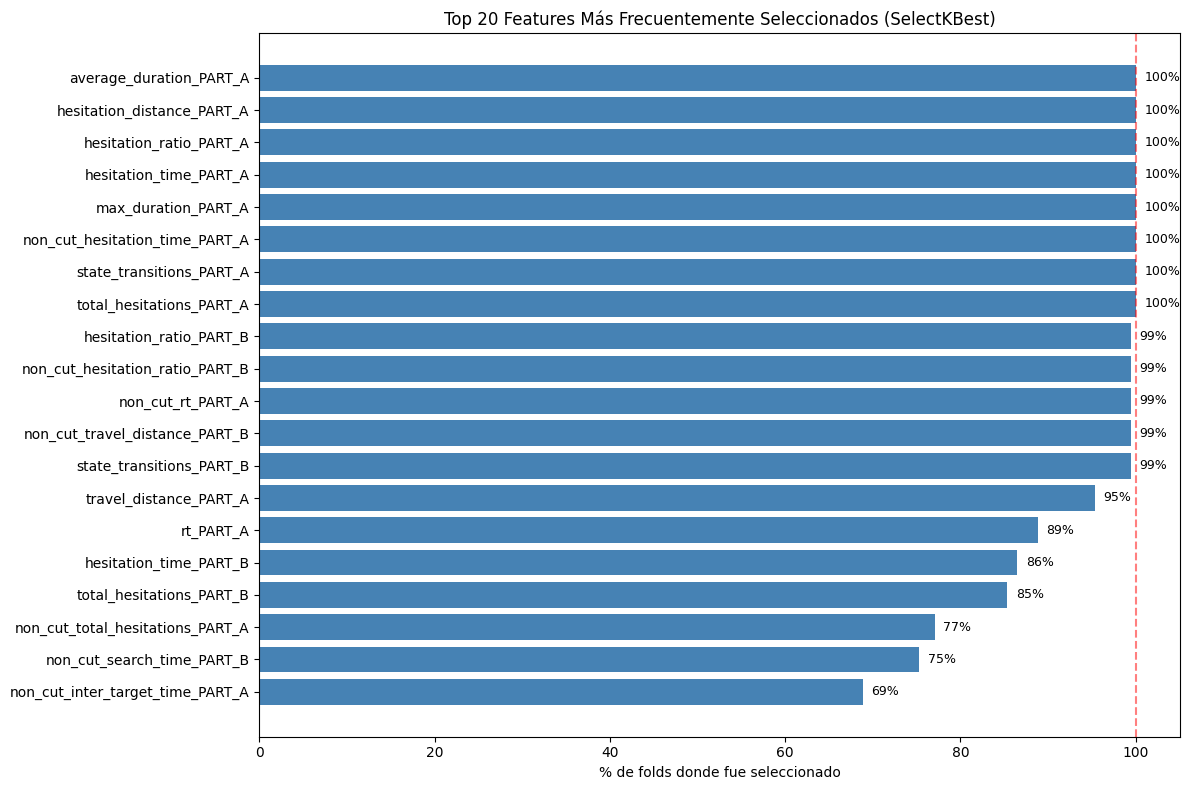


📊 Observación: Si muchos features tienen alta frecuencia (>80%), indica estabilidad en la selección.
   Si varían mucho entre folds, puede indicar que ningún feature es claramente predictivo.


In [12]:
# Visualizar frecuencia de features
fig, ax = plt.subplots(figsize=(12, 8))
top_20 = top_features_df.head(20)
bars = ax.barh(range(len(top_20)), top_20['pct_folds'], color='steelblue')
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'])
ax.invert_yaxis()
ax.set_xlabel('% de folds donde fue seleccionado')
ax.set_title('Top 20 Features Más Frecuentemente Seleccionados (SelectKBest)')
ax.axvline(100, color='red', linestyle='--', alpha=0.5, label='100% (todos los folds)')

# Anotar valores
for bar, pct in zip(bars, top_20['pct_folds']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n📊 Observación: Si muchos features tienen alta frecuencia (>80%), indica estabilidad en la selección.")
print(f"   Si varían mucho entre folds, puede indicar que ningún feature es claramente predictivo.")

## Fase 6: Análisis de Variabilidad entre Folds

Evaluamos la consistencia de los errores a través de los diferentes folds de LOOCV.

/tmp/ipykernel_3378948/3794869736.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)


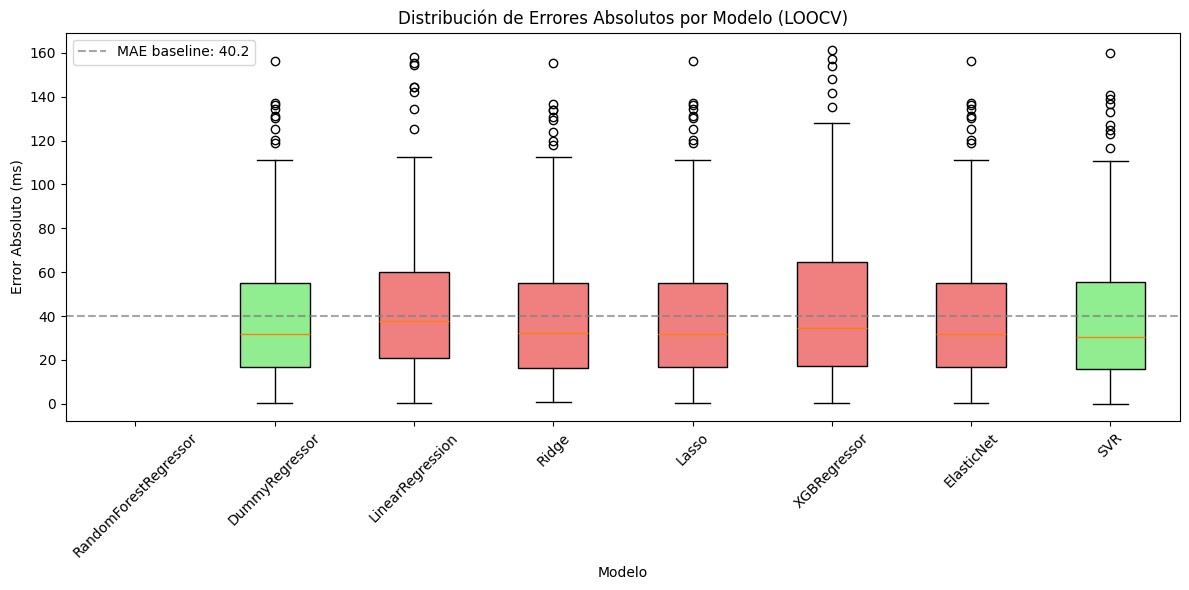

In [13]:
# Boxplot de errores absolutos por modelo
fig, ax = plt.subplots(figsize=(12, 6))

errors_by_model = []
model_names = []
for model in df['model'].unique():
    model_folds = folds[folds['model'] == model]
    errors = np.abs(model_folds['y_pred'] - model_folds['y_test'])
    errors_by_model.append(errors.values)
    model_names.append(model)

bp = ax.boxplot(errors_by_model, labels=model_names, patch_artist=True)

# Colorear por rendimiento
colors = ['lightgreen' if df[df['model']==m]['mae'].values[0] <= baseline_mae else 'lightcoral' 
          for m in model_names]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Error Absoluto (ms)')
ax.set_xlabel('Modelo')
ax.tick_params(axis='x', rotation=45)
ax.axhline(baseline_mae, color='gray', linestyle='--', alpha=0.7, label=f'MAE baseline: {baseline_mae:.1f}')
ax.legend()
ax.set_title('Distribución de Errores Absolutos por Modelo (LOOCV)')
plt.tight_layout()
plt.show()

In [14]:
# Identificar sujetos problemáticos (peores predicciones)
ridge_analysis = folds[folds['model'] == 'Ridge'].copy()
ridge_analysis['abs_error'] = np.abs(ridge_analysis['y_pred'] - ridge_analysis['y_test'])

print("=== Top 10 Sujetos con Mayor Error (Ridge) ===\n")
worst_subjects = ridge_analysis.nlargest(10, 'abs_error')[['fold', 'y_test', 'y_pred', 'abs_error']]
worst_subjects.columns = ['Fold (Sujeto)', 'SSRT Real', 'SSRT Predicho', 'Error Absoluto']
display(worst_subjects.round(1))

print(f"\n📊 Observación: Los mayores errores ocurren en sujetos con SSRT extremo")
print(f"   (muy bajo o muy alto), lo cual es esperable dado que el modelo predice cerca de la media.")

=== Top 10 Sujetos con Mayor Error (Ridge) ===



,Fold (Sujeto),SSRT Real,SSRT Predicho,Error Absoluto
489,149,69,224.6,155.6
493,153,88,224.6,136.6
452,112,91,225.1,134.1
374,34,89,222.9,133.9
509,169,354,223.3,130.7
343,3,94,223.4,129.4
350,10,100,223.8,123.8
462,122,106,225.9,119.9
494,154,344,226.2,117.8
390,50,334,221.6,112.4



📊 Observación: Los mayores errores ocurren en sujetos con SSRT extremo
   (muy bajo o muy alto), lo cual es esperable dado que el modelo predice cerca de la media.


## Fase 7: Correlaciones Features-Target

Analizamos las correlaciones univariadas entre cada feature de TMT y el target SSRT.

In [15]:
# Calcular correlaciones univariadas
correlations = df_features.drop('target', axis=1).apply(lambda x: x.corr(df_features['target']))
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("=== Top 20 Features Más Correlacionados con SSRT ===\n")
print(f"{'Feature':<50} {'r':>8} {'|r|':>8}")
print("-" * 68)
for feat in correlations_sorted.head(20).index:
    r = correlations[feat]
    abs_r = abs(r)
    print(f"{feat:<50} {r:>8.3f} {abs_r:>8.3f}")

print(f"\n📊 Observación: Correlaciones muy bajas (|r| < 0.2) indican poca relación lineal")
print(f"   entre los features de TMT y el SSRT.")

=== Top 20 Features Más Correlacionados con SSRT ===

Feature                                                   r      |r|
--------------------------------------------------------------------
hesitation_time_PART_A                                0.190    0.190
state_transitions_PART_A                              0.182    0.182
hesitation_ratio_PART_A                               0.180    0.180
max_duration_PART_A                                   0.180    0.180
hesitation_distance_PART_A                            0.176    0.176
total_hesitations_PART_A                              0.161    0.161
average_duration_PART_A                               0.152    0.152
non_cut_rt_PART_A                                     0.149    0.149
non_cut_hesitation_ratio_PART_B                       0.147    0.147
hesitation_ratio_PART_B                               0.144    0.144
non_cut_travel_distance_PART_B                       -0.141    0.141
non_cut_hesitation_time_PART_A                   

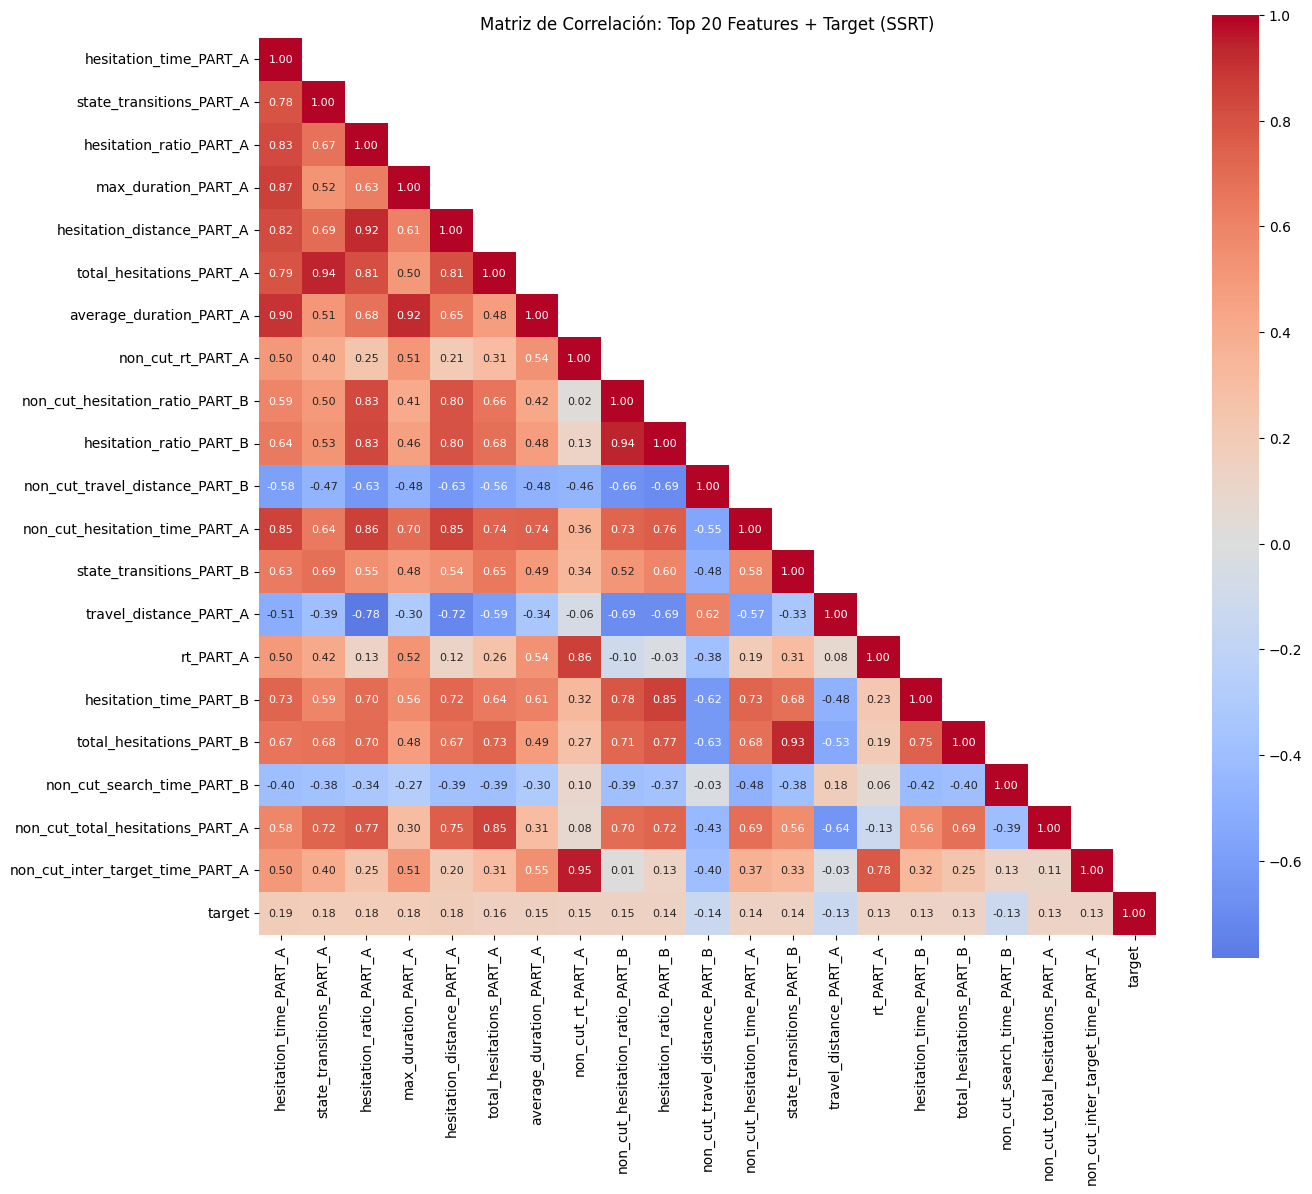

In [16]:
# Heatmap de correlaciones (top 20 features + target)
top_20_features = correlations_sorted.head(20).index.tolist()
subset = df_features[top_20_features + ['target']]

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = subset.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, annot_kws={'size': 8}, square=True)
ax.set_title('Matriz de Correlación: Top 20 Features + Target (SSRT)')
plt.tight_layout()
plt.show()

## Fase 8: Test de Permutación

Validamos estadísticamente si el rendimiento de los modelos es mejor que el azar usando el módulo existente.

In [17]:
# Usar p-values pre-calculados del consolidated
print("=== Test de Permutacion (1000 permutaciones, metrica: MAE) ===\n")

perm_df = df[['model', 'mae', 'p_value_mae']].copy()
perm_df = perm_df.rename(columns={'p_value_mae': 'p_value'})
perm_df['significant'] = perm_df['p_value'] < 0.05
perm_df = perm_df.sort_values('mae')

print("=== Resultados ===\n")
display(perm_df)

=== Test de Permutacion (1000 permutaciones, metrica: MAE) ===

=== Resultados ===



,model,mae,p_value,significant
7,SVR,39.997860,0.796204,False
1,DummyRegressor,40.150644,1.000000,False
6,ElasticNet,40.159744,1.000000,False
4,Lasso,40.202553,1.000000,False
3,Ridge,40.261444,0.995005,False
0,RandomForestRegressor,42.644893,0.999001,False
5,XGBRegressor,44.818549,0.561439,False
2,LinearRegression,45.079147,0.968032,False


In [18]:
print("=== Interpretación del Test de Permutación ===")
print(f"\nModelos con p < 0.05 (significativo): {perm_df['significant'].sum()}/{len(perm_df)}")
print(f"Modelos con p >= 0.05 (no significativo): {(~perm_df['significant']).sum()}/{len(perm_df)}")

if perm_df['significant'].any():
    print(f"\n✅ Modelos significativos:")
    for _, row in perm_df[perm_df['significant']].iterrows():
        print(f"   - {row['model']}: MAE={row['mae']:.2f}, p={row['p_value']:.4f}")
else:
    print(f"\n❌ NINGÚN modelo es estadísticamente significativo (p < 0.05)")
    print("   Esto confirma que los modelos no predicen mejor que el azar.")

=== Interpretación del Test de Permutación ===

Modelos con p < 0.05 (significativo): 0/8
Modelos con p >= 0.05 (no significativo): 8/8

❌ NINGÚN modelo es estadísticamente significativo (p < 0.05)
   Esto confirma que los modelos no predicen mejor que el azar.


## Conclusiones y Recomendaciones

### Resumen de Hallazgos

In [19]:
print("=" * 70)
print("                    RESUMEN EJECUTIVO - TMT → SSRT")
print("=" * 70)

print("""
❌ PROBLEMAS CRÍTICOS:
   1. Todos los modelos tienen R² negativo (peor que predecir la media)
   2. El mejor modelo (SVR) apenas iguala al baseline DummyRegressor
   3. Los modelos complejos (XGB, RF) tienen peor rendimiento que los simples

⚠️ ADVERTENCIAS:
   1. Dataset pequeño (n=170) con muchos features (170)
   2. Feature selection selecciona 20 features que varían entre folds
   3. Correlaciones features-target muy bajas (|r| < 0.2)

✅ ASPECTOS CORRECTOS:
   1. Implementación de LOOCV sin data leakage
   2. Pipeline de preprocessing correcto
   3. Nested CV para hyperparameter tuning
   4. DummyRegressor incluido como baseline

💡 RECOMENDACIONES:
   1. No usar estos modelos para predicción de SSRT
   2. Investigar la base teórica: ¿TMT debería predecir SSRT?
   3. Explorar otros targets (K_6, sensibilidad muestran mejor señal)
   4. Considerar agregar features de otras tareas cognitivas
   5. Reducir dimensionalidad antes de feature selection

📊 PRÓXIMOS PASOS:
   1. Analizar en profundidad los otros targets (K_6, sensibilidad)
   2. Explorar interacciones entre features
   3. Considerar modelos no lineales con regularización más fuerte
   4. Consultar literatura sobre relación TMT-SST
""")

print("=" * 70)
print("VEREDICTO: ❌ Los modelos NO funcionan para predecir SSRT desde TMT")
print("=" * 70)

                    RESUMEN EJECUTIVO - TMT → SSRT

❌ PROBLEMAS CRÍTICOS:
   1. Todos los modelos tienen R² negativo (peor que predecir la media)
   2. El mejor modelo (SVR) apenas iguala al baseline DummyRegressor
   3. Los modelos complejos (XGB, RF) tienen peor rendimiento que los simples

⚠️ ADVERTENCIAS:
   1. Dataset pequeño (n=170) con muchos features (170)
   2. Feature selection selecciona 20 features que varían entre folds
   3. Correlaciones features-target muy bajas (|r| < 0.2)

✅ ASPECTOS CORRECTOS:
   1. Implementación de LOOCV sin data leakage
   2. Pipeline de preprocessing correcto
   3. Nested CV para hyperparameter tuning
   4. DummyRegressor incluido como baseline

💡 RECOMENDACIONES:
   1. No usar estos modelos para predicción de SSRT
   2. Investigar la base teórica: ¿TMT debería predecir SSRT?
   3. Explorar otros targets (K_6, sensibilidad muestran mejor señal)
   4. Considerar agregar features de otras tareas cognitivas
   5. Reducir dimensionalidad antes de fea